# Lego Minifig — Model Comparison
## EfficientNet-B0 vs ResNet-50

**Goal:** Train both models on the same data pipeline and compare performance.

| Step | Description |
|------|-------------|
| 1 | Data loading, cleaning, splits, DataLoaders |
| 2 | Train EfficientNet-B0 (Phase 1 + Phase 2) |
| 3 | Train ResNet-50 (Phase 1 + Phase 2) |
| 4 | Overfitting analysis |
| 5 | Metric comparison |
| 6 | Confusion matrices |
| 7 | Per-class accuracy comparison |
| 8 | Grad-CAM (best model) |
| 9 | Final summary + save reports |

## 0. Setup

In [1]:
import sys
import time
import json
import logging
import warnings
import numpy as np
import torch
from pathlib import Path
from sklearn.metrics import classification_report, confusion_matrix

warnings.filterwarnings('ignore')

# Add project root to path
NOTEBOOK_DIR = Path('__file__').resolve().parent
BASE_DIR     = NOTEBOOK_DIR.parent                    # Final_assignment_2/
PROJECT_DIR  = BASE_DIR.parent                        # project/
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))
if str(BASE_DIR) not in sys.path:
    sys.path.insert(0, str(BASE_DIR))

from Final_assignment_2.src import config
from Final_assignment_2.src.data_utils import (
    load_and_clean, create_label_encoding, split_data, create_dataloaders
)
from Final_assignment_2.src.models import MinifigClassifier, count_parameters
from Final_assignment_2.src.trainer import (
    train_model, evaluate_epoch, compute_metrics,
    save_checkpoint, ModelResult, EvalResult
)
from Final_assignment_2.src.visualisation import (
    plot_training_curves, plot_overfitting_comparison,
    plot_model_comparison, plot_confusion_matrix,
    plot_per_class_accuracy_comparison,
    plot_gradcam_grid, build_gradcam_results
)

# Logging
logging.basicConfig(
    level=logging.INFO,
    format='[%(asctime)s] %(levelname)-8s %(name)s - %(message)s',
    datefmt='%H:%M:%S'
)

# Reproducibility
torch.manual_seed(config.SEED)
np.random.seed(config.SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device  : {DEVICE}')
print(f'Base dir: {BASE_DIR}')

Device  : cpu
Base dir: C:\Users\ekung\Desktop\KU Lueven\semester2\big data\Assignment\Assignment 2\project\Final_assignment_2


## 1. Data Pipeline

In [2]:
# Load and clean
df, valid_categories, cat_counts = load_and_clean(
    json_path   = config.JSON_PATH,
    image_dir   = config.IMAGE_DIR,
    min_samples = config.MIN_SAMPLES,
)

print(f'Dataset       : {len(df)} images')
print(f'Classes kept  : {len(valid_categories)}')
print(f'Imbalance ratio (max/min): {cat_counts.iloc[0] / cat_counts.iloc[-1]:.1f}x')

[16:15:34] INFO     Final_assignment_2.src.data_utils - Loaded 17362 records
[16:15:35] INFO     Final_assignment_2.src.data_utils - Images verified: 17361 records remain
[16:15:35] INFO     Final_assignment_2.src.data_utils - Kept 28/122 categories with >=100 images → 14791 rows


Dataset       : 14791 images
Classes kept  : 28
Imbalance ratio (max/min): 31.4x


In [3]:
# Label encoding and splits
label_mapping = create_label_encoding(valid_categories)
splits        = split_data(df, config.TRAIN_RATIO, config.VAL_RATIO, config.SEED)

print(f'Train : {len(splits.train_df)}')
print(f'Val   : {len(splits.val_df)}')
print(f'Test  : {len(splits.test_df)}')
print(f'Classes: {label_mapping.num_classes}')

[16:15:38] INFO     Final_assignment_2.src.data_utils - Split → train:10353  val:2218  test:2220


Train : 10353
Val   : 2218
Test  : 2220
Classes: 28


In [4]:
# DataLoaders — same loaders used for BOTH models (fair comparison)
loaders = create_dataloaders(
    splits        = splits,
    image_dir     = config.IMAGE_DIR,
    label_mapping = label_mapping,
    batch_size    = config.BATCH_SIZE,
    num_workers   = config.NUM_WORKERS,
    pin_memory    = config.PIN_MEMORY,
    img_size      = config.IMG_SIZE,
    resize_size   = config.RESIZE_SIZE,
    mean          = config.IMAGENET_MEAN,
    std           = config.IMAGENET_STD,
)

# Quick sanity check
imgs, labels = next(iter(loaders.train))
print(f'Batch shape : {imgs.shape}   Labels shape: {labels.shape}')

[16:15:41] INFO     Final_assignment_2.src.data_utils - DataLoaders ready — train:10353  val:2218  test:2220


Batch shape : torch.Size([64, 3, 224, 224])   Labels shape: torch.Size([64])


## 2. Train EfficientNet-B0

In [5]:
eff_model = MinifigClassifier(
    backbone_name = 'efficientnet_b0',
    num_classes   = label_mapping.num_classes,
    dropout_rate  = config.DROPOUT_RATE,
).to(DEVICE)

eff_params = count_parameters(eff_model)
print(f'EfficientNet-B0 — Total params: {eff_params["total"]:,}  |  Trainable: {eff_params["trainable"]:,}')

EfficientNet-B0 — Total params: 4,045,976  |  Trainable: 4,045,976


In [6]:
print('Training EfficientNet-B0...')
t0 = time.time()

eff_history = train_model(
    model                   = eff_model,
    train_loader            = loaders.train,
    val_loader              = loaders.val,
    device                  = DEVICE,
    label_smoothing         = config.LABEL_SMOOTHING,
    phase1_epochs           = config.PHASE1_EPOCHS,
    phase1_lr               = config.PHASE1_LR,
    phase2_epochs           = config.PHASE2_EPOCHS,
    phase2_lr_early         = config.PHASE2_LR_EARLY_LAYERS,
    phase2_lr_late          = config.PHASE2_LR_LATE_LAYERS,
    phase2_lr_head          = config.PHASE2_LR_HEAD,
    early_stopping_patience = config.EARLY_STOPPING_PATIENCE,
    grad_clip               = config.GRAD_CLIP_NORM,
)

eff_train_time = time.time() - t0
print(f'EfficientNet-B0 training done in {eff_train_time/60:.1f} min')

[16:15:51] INFO     Final_assignment_2.src.trainer - Phase 1 — 5 epochs (backbone frozen)


Training EfficientNet-B0...


[16:21:26] INFO     Final_assignment_2.src.trainer -   P1 Epoch  1/5 | train_loss=2.3631 acc=0.409 | val_loss=2.1002 acc=0.467
[16:28:42] INFO     Final_assignment_2.src.trainer -   P1 Epoch  2/5 | train_loss=1.9733 acc=0.539 | val_loss=2.0879 acc=0.467
[16:33:40] INFO     Final_assignment_2.src.trainer -   P1 Epoch  3/5 | train_loss=1.9007 acc=0.568 | val_loss=2.1071 acc=0.469
[16:38:10] INFO     Final_assignment_2.src.trainer -   P1 Epoch  4/5 | train_loss=1.8633 acc=0.578 | val_loss=1.9977 acc=0.501
[16:42:26] INFO     Final_assignment_2.src.trainer -   P1 Epoch  5/5 | train_loss=1.8135 acc=0.598 | val_loss=1.9403 acc=0.528
[16:42:26] INFO     Final_assignment_2.src.trainer - Phase 2 — up to 20 epochs (full fine-tune)
[16:52:44] INFO     Final_assignment_2.src.trainer -   P2 Epoch  1/20 | train_loss=1.7212 acc=0.634 | val_loss=1.8504 acc=0.568
[17:02:27] INFO     Final_assignment_2.src.trainer -   P2 Epoch  2/20 | train_loss=1.5542 acc=0.699 | val_loss=1.7351 acc=0.616
[17:12:19] IN

EfficientNet-B0 training done in 279.3 min


In [7]:
# Evaluate EfficientNet on test set
import torch.nn as nn
criterion = nn.CrossEntropyLoss(label_smoothing=config.LABEL_SMOOTHING)
_, _, eff_eval = evaluate_epoch(eff_model, loaders.test, criterion, DEVICE)
eff_metrics    = compute_metrics(eff_eval, label_mapping.num_classes)

print(f'EfficientNet-B0 Results:')
print(f'  Accuracy   : {eff_metrics.accuracy:.4f} ({eff_metrics.accuracy*100:.1f}%)')
print(f'  Macro F1   : {eff_metrics.macro_f1:.4f}')
print(f'  Weighted F1: {eff_metrics.weighted_f1:.4f}')
print(f'  Top-3 Acc  : {eff_metrics.top3_acc:.4f} ({eff_metrics.top3_acc*100:.1f}%)')

# Save checkpoint
save_checkpoint(
    eff_model,
    config.MODELS_DIR / 'efficientnet_b0_best.pth',
    label_mapping,
    eff_metrics
)

[20:57:25] INFO     Final_assignment_2.src.trainer - Checkpoint saved → C:\Users\ekung\Desktop\KU Lueven\semester2\big data\Assignment\Assignment 2\project\Final_assignment_2\outputs\models\efficientnet_b0_best.pth


EfficientNet-B0 Results:
  Accuracy   : 0.7320 (73.2%)
  Macro F1   : 0.7026
  Weighted F1: 0.7423
  Top-3 Acc  : 0.8928 (89.3%)


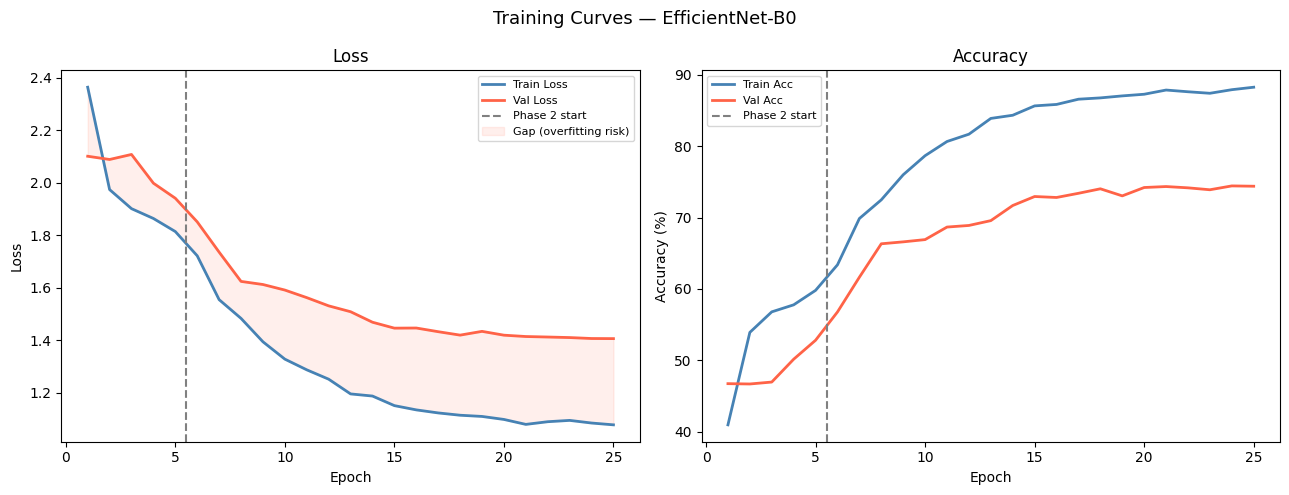

In [8]:
# Training curves for EfficientNet
plot_training_curves(
    eff_history,
    model_name = 'EfficientNet-B0',
    save_path  = config.FIGURES_DIR / 'eff_training_curves.png',
    show       = True,
)

## 3. Train ResNet-50

In [9]:
res_model = MinifigClassifier(
    backbone_name = 'resnet50',
    num_classes   = label_mapping.num_classes,
    dropout_rate  = config.DROPOUT_RATE,
).to(DEVICE)

res_params = count_parameters(res_model)
print(f'ResNet-50 — Total params: {res_params["total"]:,}  |  Trainable: {res_params["trainable"]:,}')

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to C:\Users\ekung/.cache\torch\hub\checkpoints\resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:32<00:00, 3.20MB/s]


ResNet-50 — Total params: 23,569,500  |  Trainable: 23,569,500


In [11]:
print('Training ResNet-50...')
t0 = time.time()

res_history = train_model(
    model                   = res_model,
    train_loader            = loaders.train,
    val_loader              = loaders.val,
    device                  = DEVICE,
    label_smoothing         = config.LABEL_SMOOTHING,
    phase1_epochs           = config.PHASE1_EPOCHS,
    phase1_lr               = config.PHASE1_LR,
    phase2_epochs           = config.PHASE2_EPOCHS,
    phase2_lr_early         = config.PHASE2_LR_EARLY_LAYERS,
    phase2_lr_late          = config.PHASE2_LR_LATE_LAYERS,
    phase2_lr_head          = config.PHASE2_LR_HEAD,
    early_stopping_patience = config.EARLY_STOPPING_PATIENCE,
    grad_clip               = config.GRAD_CLIP_NORM,
)

res_train_time = time.time() - t0
print(f'ResNet-50 training done in {res_train_time/60:.1f} min')

[22:11:04] INFO     Final_assignment_2.src.trainer - Phase 1 — 5 epochs (backbone frozen)


Training ResNet-50...


[22:21:09] INFO     Final_assignment_2.src.trainer -   P1 Epoch  1/5 | train_loss=1.5943 acc=0.688 | val_loss=1.9426 acc=0.556
[22:30:40] INFO     Final_assignment_2.src.trainer -   P1 Epoch  2/5 | train_loss=1.5772 acc=0.690 | val_loss=1.9758 acc=0.562
[22:40:28] INFO     Final_assignment_2.src.trainer -   P1 Epoch  3/5 | train_loss=1.5541 acc=0.701 | val_loss=1.7645 acc=0.614
[22:50:17] INFO     Final_assignment_2.src.trainer -   P1 Epoch  4/5 | train_loss=1.5549 acc=0.701 | val_loss=1.8581 acc=0.588
[23:00:02] INFO     Final_assignment_2.src.trainer -   P1 Epoch  5/5 | train_loss=1.5483 acc=0.701 | val_loss=1.7658 acc=0.621
[23:00:02] INFO     Final_assignment_2.src.trainer - Phase 2 — up to 20 epochs (full fine-tune)
[23:22:08] INFO     Final_assignment_2.src.trainer -   P2 Epoch  1/20 | train_loss=1.4565 acc=0.743 | val_loss=1.7017 acc=0.657
[23:44:25] INFO     Final_assignment_2.src.trainer -   P2 Epoch  2/20 | train_loss=1.2566 acc=0.815 | val_loss=1.5479 acc=0.707
[00:07:06] IN

ResNet-50 training done in 474.7 min


In [12]:
# Evaluate ResNet on test set
_, _, res_eval = evaluate_epoch(res_model, loaders.test, criterion, DEVICE)
res_metrics    = compute_metrics(res_eval, label_mapping.num_classes)

print(f'ResNet-50 Results:')
print(f'  Accuracy   : {res_metrics.accuracy:.4f} ({res_metrics.accuracy*100:.1f}%)')
print(f'  Macro F1   : {res_metrics.macro_f1:.4f}')
print(f'  Weighted F1: {res_metrics.weighted_f1:.4f}')
print(f'  Top-3 Acc  : {res_metrics.top3_acc:.4f} ({res_metrics.top3_acc*100:.1f}%)')

save_checkpoint(
    res_model,
    config.MODELS_DIR / 'resnet50_best.pth',
    label_mapping,
    res_metrics
)

[09:02:07] INFO     Final_assignment_2.src.trainer - Checkpoint saved → C:\Users\ekung\Desktop\KU Lueven\semester2\big data\Assignment\Assignment 2\project\Final_assignment_2\outputs\models\resnet50_best.pth


ResNet-50 Results:
  Accuracy   : 0.8149 (81.5%)
  Macro F1   : 0.7677
  Weighted F1: 0.8134
  Top-3 Acc  : 0.9329 (93.3%)


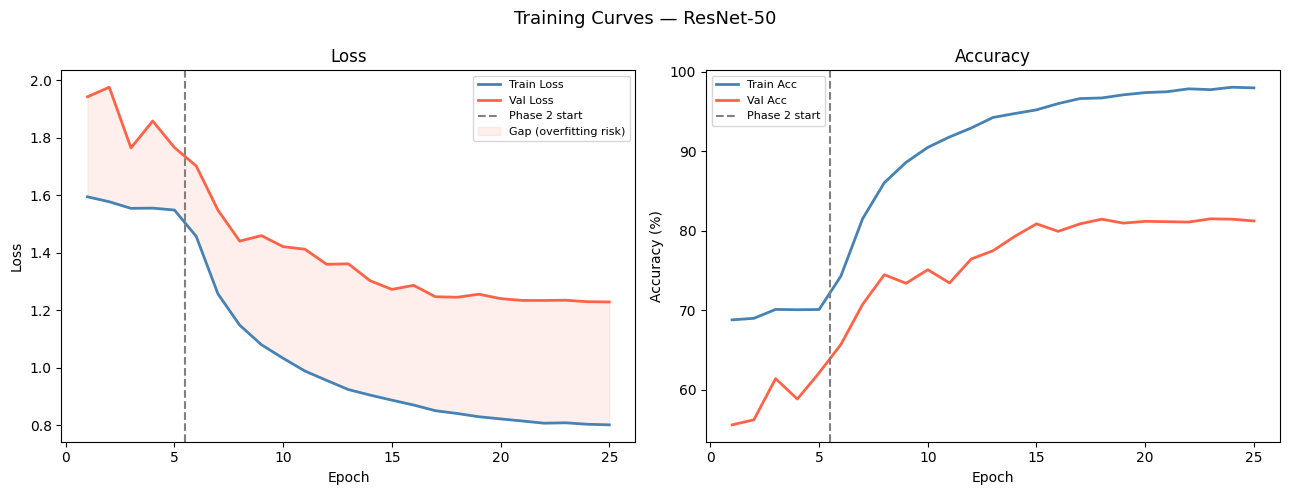

In [13]:
# Training curves for ResNet
plot_training_curves(
    res_history,
    model_name = 'ResNet-50',
    save_path  = config.FIGURES_DIR / 'res_training_curves.png',
    show       = True,
)

## 4. Overfitting Analysis

**How to read these plots:**
- If `val_loss` closely follows `train_loss` → **no overfitting** (good)
- If `train_loss` keeps falling but `val_loss` rises → **overfitting** (bad)
- The Loss Gap plot (val − train) should stay small and stable

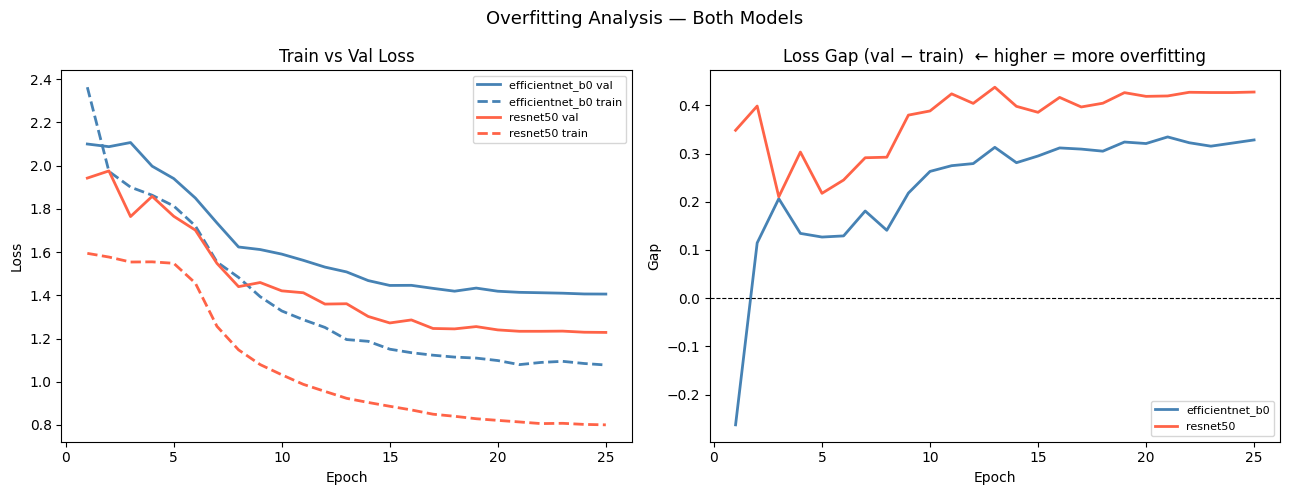

Overfitting score (avg loss gap, last 5 epochs):
  EfficientNet-B0 : 0.3245
  ResNet-50       : 0.4255
  (lower = less overfitting)


In [14]:
plot_overfitting_comparison(
    histories = {
        'efficientnet_b0': eff_history,
        'resnet50':        res_history,
    },
    save_path = config.FIGURES_DIR / 'overfitting_comparison.png',
    show      = True,
)

# Overfitting score = average loss gap in last 5 epochs
def overfitting_score(hist, last_n=5):
    gaps = [v - t for v, t in zip(hist.val_loss[-last_n:], hist.train_loss[-last_n:])]
    return np.mean(gaps)

print(f'Overfitting score (avg loss gap, last 5 epochs):')
print(f'  EfficientNet-B0 : {overfitting_score(eff_history):.4f}')
print(f'  ResNet-50       : {overfitting_score(res_history):.4f}')
print('  (lower = less overfitting)')

## 5. Model Comparison

In [15]:
# Summary comparison table
import pandas as pd

comparison = pd.DataFrame({
    'Metric':          ['Accuracy', 'Macro F1', 'Weighted F1', 'Top-3 Acc',
                        'Parameters', 'Train Time (min)'],
    'EfficientNet-B0': [
        f"{eff_metrics.accuracy*100:.1f}%",
        f"{eff_metrics.macro_f1:.3f}",
        f"{eff_metrics.weighted_f1:.3f}",
        f"{eff_metrics.top3_acc*100:.1f}%",
        f"{eff_params['total']:,}",
        f"{eff_train_time/60:.1f}",
    ],
    'ResNet-50': [
        f"{res_metrics.accuracy*100:.1f}%",
        f"{res_metrics.macro_f1:.3f}",
        f"{res_metrics.weighted_f1:.3f}",
        f"{res_metrics.top3_acc*100:.1f}%",
        f"{res_params['total']:,}",
        f"{res_train_time/60:.1f}",
    ],
})
print(comparison.to_string(index=False))

          Metric EfficientNet-B0  ResNet-50
        Accuracy           73.2%      81.5%
        Macro F1           0.703      0.768
     Weighted F1           0.742      0.813
       Top-3 Acc           89.3%      93.3%
      Parameters       4,045,976 23,569,500
Train Time (min)           279.3      474.7


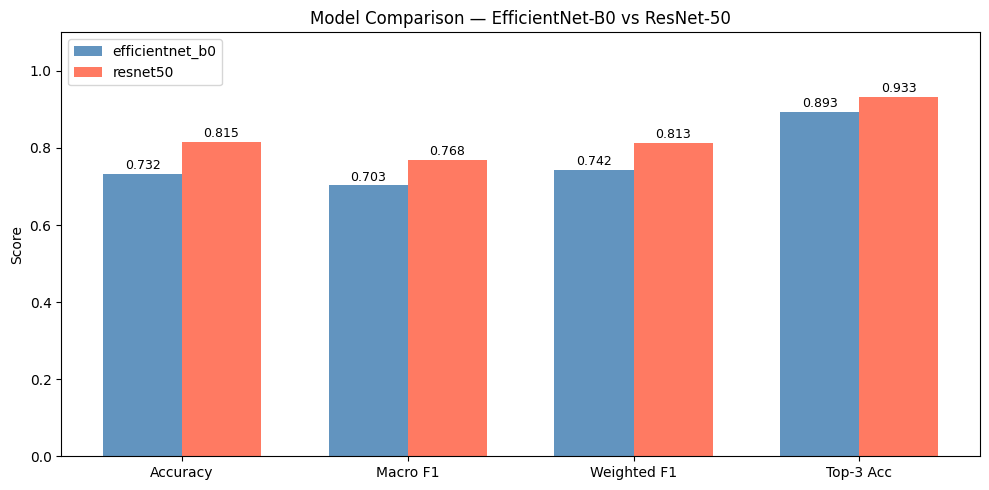

In [16]:
# Build results dict for plotting
results = {
    'efficientnet_b0': ModelResult(
        model_name  = 'efficientnet_b0',
        history     = eff_history,
        eval_result = eff_eval,
        metrics     = eff_metrics,
        train_time  = eff_train_time,
        num_params  = eff_params['total'],
    ),
    'resnet50': ModelResult(
        model_name  = 'resnet50',
        history     = res_history,
        eval_result = res_eval,
        metrics     = res_metrics,
        train_time  = res_train_time,
        num_params  = res_params['total'],
    ),
}

plot_model_comparison(
    results,
    save_path = config.FIGURES_DIR / 'model_comparison.png',
    show      = True,
)

## 6. Confusion Matrices

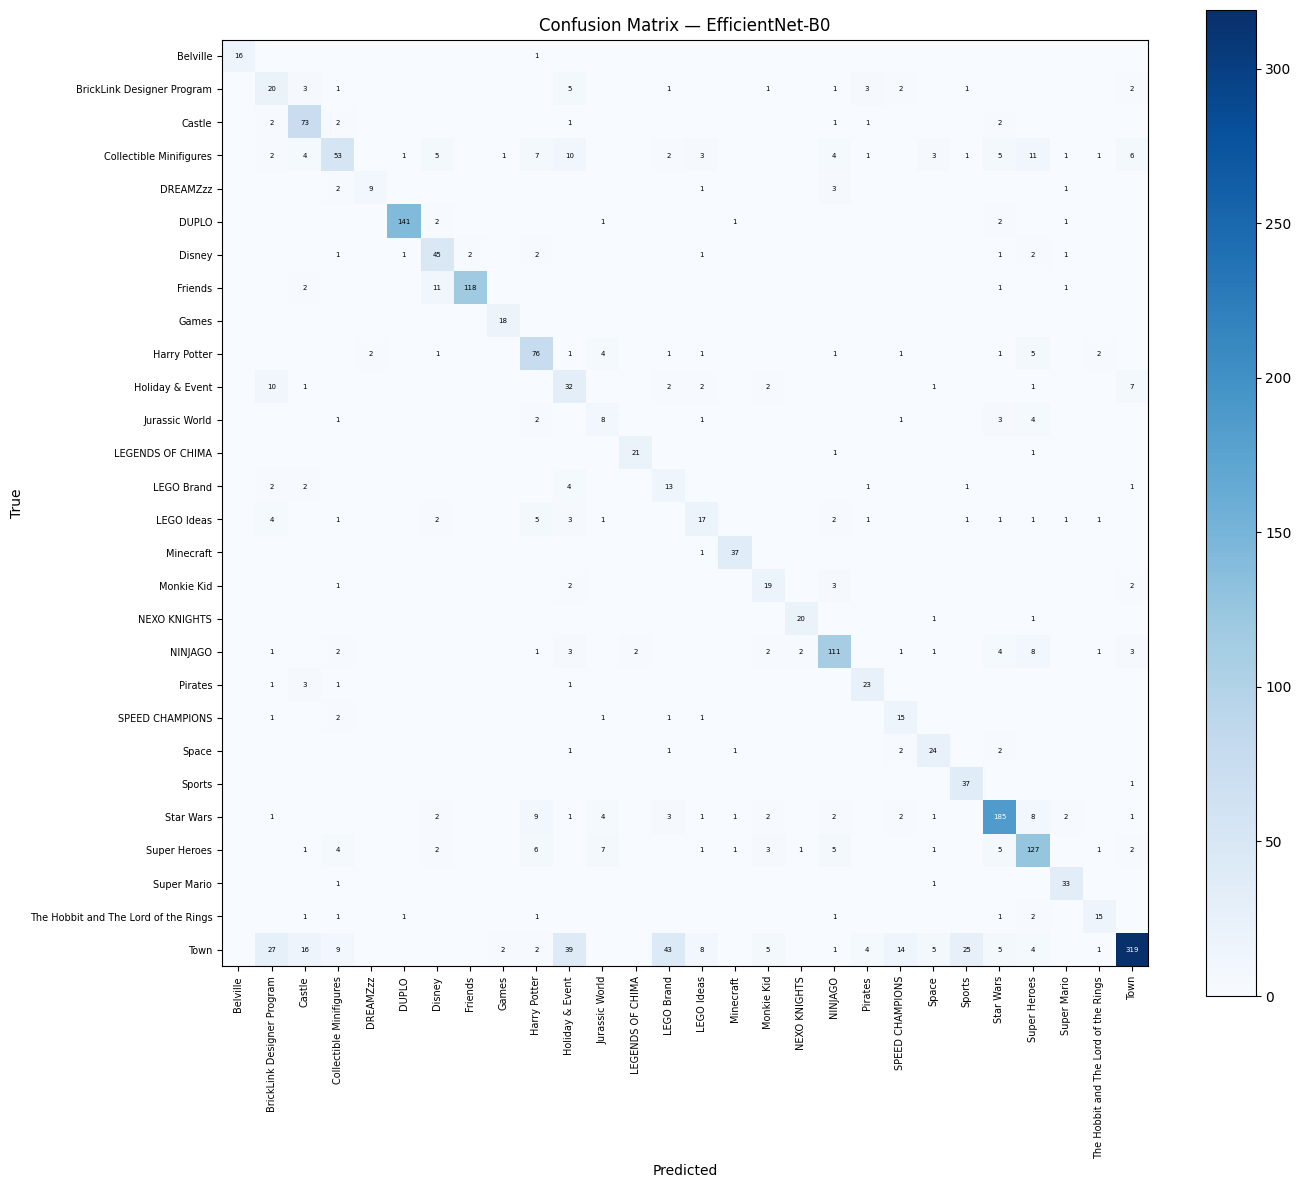

In [17]:
target_names = [label_mapping.idx2label[i] for i in range(label_mapping.num_classes)]

eff_cm = confusion_matrix(eff_eval.labels, eff_eval.preds)
res_cm = confusion_matrix(res_eval.labels, res_eval.preds)

plot_confusion_matrix(
    eff_cm, target_names,
    title     = 'Confusion Matrix — EfficientNet-B0',
    save_path = config.FIGURES_DIR / 'cm_efficientnet.png',
    show      = True,
)

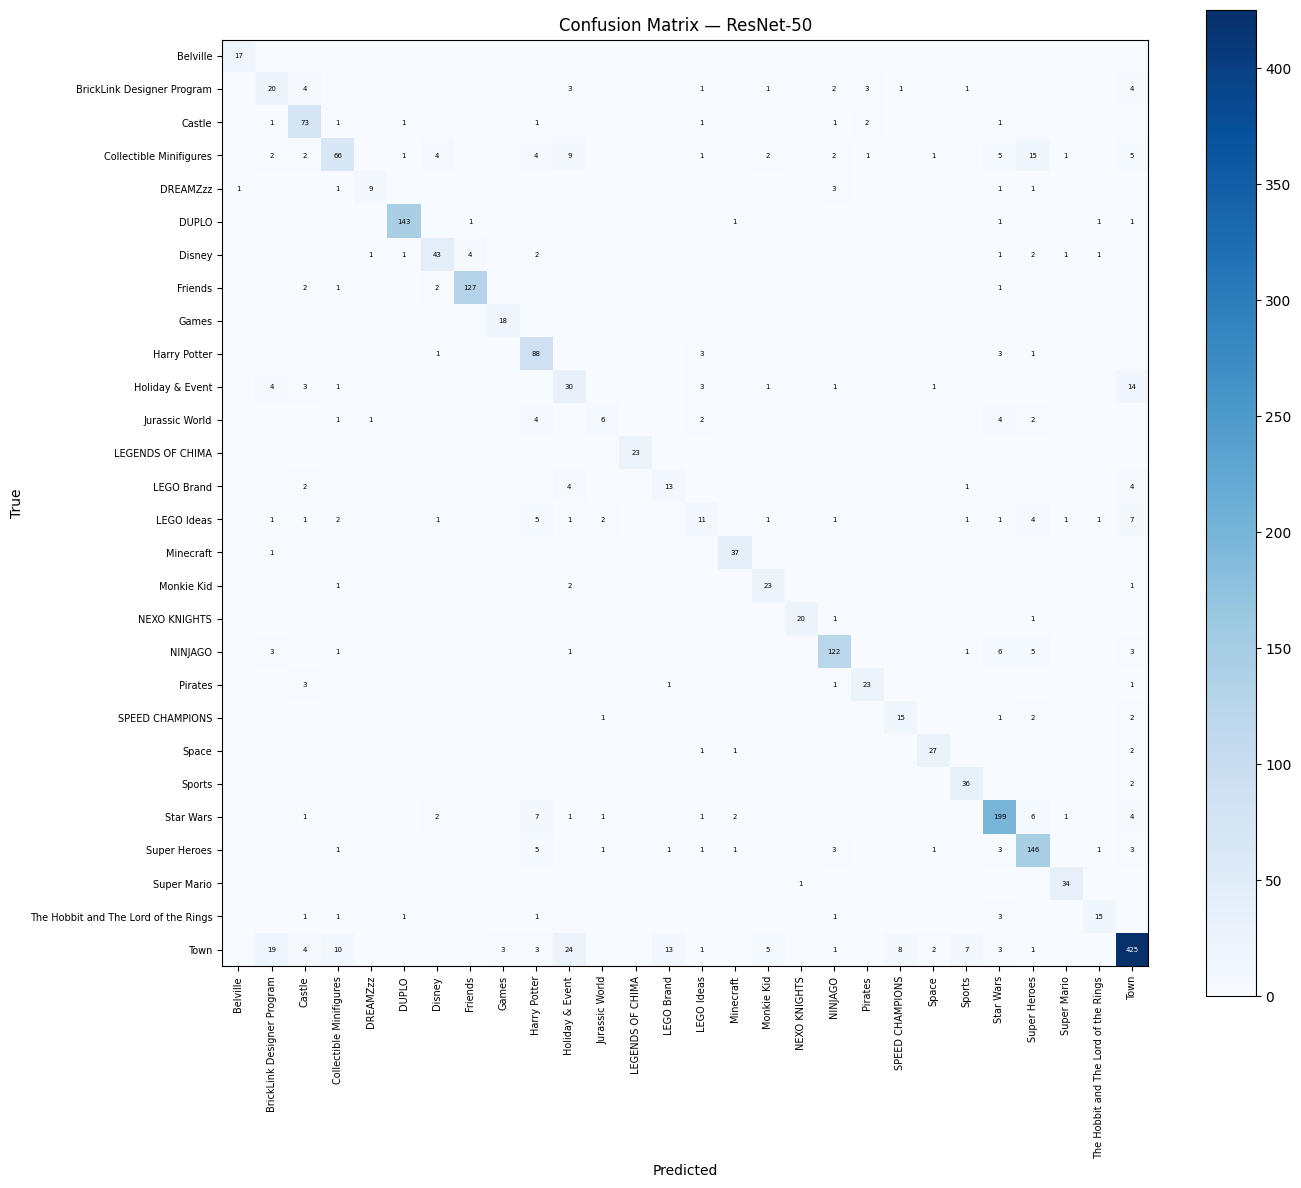

In [18]:
plot_confusion_matrix(
    res_cm, target_names,
    title     = 'Confusion Matrix — ResNet-50',
    save_path = config.FIGURES_DIR / 'cm_resnet50.png',
    show      = True,
)

## 7. Per-Class Accuracy Comparison

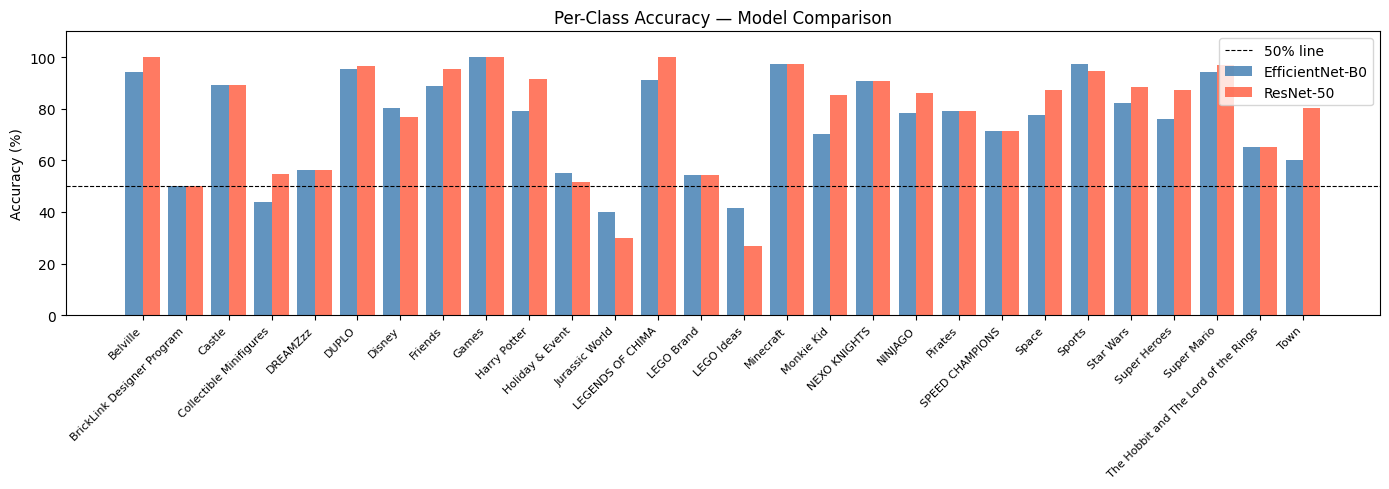

In [19]:
plot_per_class_accuracy_comparison(
    eff_cm, res_cm,
    class_names = target_names,
    name1       = 'EfficientNet-B0',
    name2       = 'ResNet-50',
    save_path   = config.FIGURES_DIR / 'per_class_accuracy_comparison.png',
    show        = True,
)

In [20]:
# Print classification reports for both
print('=== EfficientNet-B0 Classification Report ===')
print(classification_report(eff_eval.labels, eff_eval.preds,
                             target_names=target_names, digits=3))

print('=== ResNet-50 Classification Report ===')
print(classification_report(res_eval.labels, res_eval.preds,
                             target_names=target_names, digits=3))

=== EfficientNet-B0 Classification Report ===
                                      precision    recall  f1-score   support

                            Belville      1.000     0.941     0.970        17
          BrickLink Designer Program      0.282     0.500     0.360        40
                              Castle      0.689     0.890     0.777        82
             Collectible Minifigures      0.646     0.438     0.522       121
                            DREAMZzz      0.818     0.562     0.667        16
                               DUPLO      0.979     0.953     0.966       148
                              Disney      0.643     0.804     0.714        56
                             Friends      0.983     0.887     0.933       133
                               Games      0.857     1.000     0.923        18
                        Harry Potter      0.679     0.792     0.731        96
                     Holiday & Event      0.311     0.552     0.398        58
                 

## 8. Grad-CAM — Best Model
Visualise what the best model focuses on when making predictions.

Best model: ResNet-50


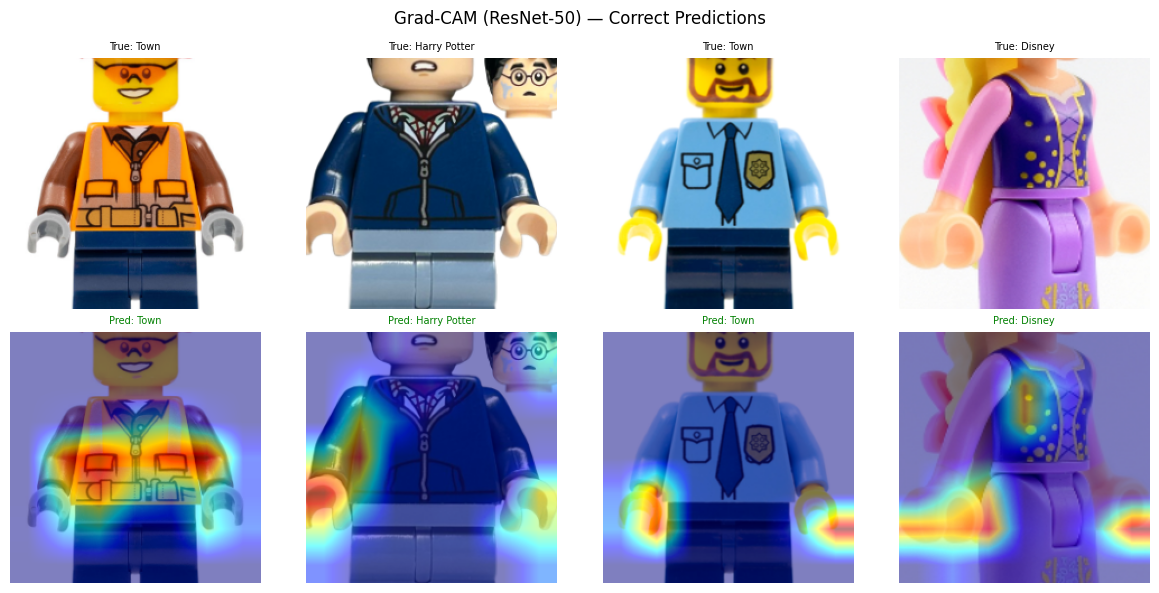

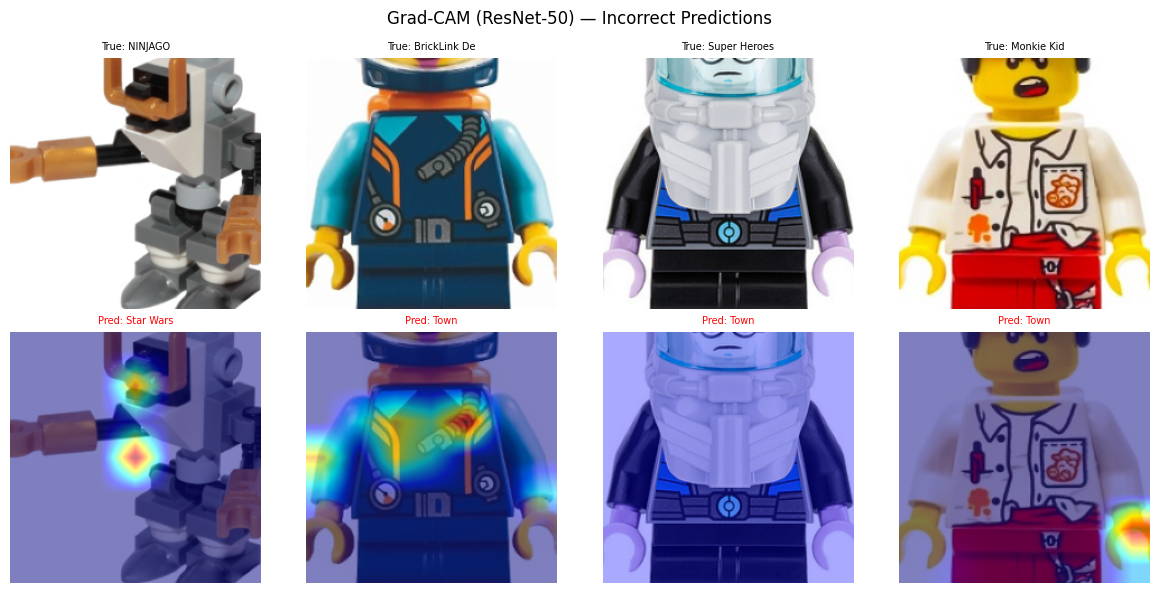

In [21]:
# Pick best model based on accuracy
if eff_metrics.accuracy >= res_metrics.accuracy:
    best_model      = eff_model
    best_model_name = 'EfficientNet-B0'
else:
    best_model      = res_model
    best_model_name = 'ResNet-50'

print(f'Best model: {best_model_name}')

rng           = np.random.default_rng(config.SEED)
test_dataset  = loaders.test.dataset
correct_idx   = [i for i, (p, l) in enumerate(zip(
    eff_eval.preds if best_model_name == 'EfficientNet-B0' else res_eval.preds,
    eff_eval.labels if best_model_name == 'EfficientNet-B0' else res_eval.labels
)) if p == l]
incorrect_idx = [i for i, (p, l) in enumerate(zip(
    eff_eval.preds if best_model_name == 'EfficientNet-B0' else res_eval.preds,
    eff_eval.labels if best_model_name == 'EfficientNet-B0' else res_eval.labels
)) if p != l]

for label, pool in [('correct', correct_idx), ('incorrect', incorrect_idx)]:
    if pool:
        sample       = rng.choice(pool, size=min(4, len(pool)), replace=False).tolist()
        gradcam_data = build_gradcam_results(
            best_model, test_dataset, sample, label_mapping.idx2label, DEVICE
        )
        if gradcam_data:
            plot_gradcam_grid(
                original_imgs = [d['orig_img']  for d in gradcam_data],
                cam_imgs      = [d['cam_img']   for d in gradcam_data],
                true_names    = [d['true_name'] for d in gradcam_data],
                pred_names    = [d['pred_name'] for d in gradcam_data],
                title         = f'Grad-CAM ({best_model_name}) — {label.capitalize()} Predictions',
                save_path     = config.FIGURES_DIR / f'gradcam_{label}.png',
                show          = True,
            )

## 9. Final Summary & Save Reports

In [22]:
print('=' * 60)
print('FINAL SUMMARY')
print('=' * 60)
print(f'Dataset        : {len(df)} images  |  {label_mapping.num_classes} classes')
print(f'Train/Val/Test : {len(splits.train_df)} / {len(splits.val_df)} / {len(splits.test_df)}')
print()
print(f'{"Metric":<20} {"EfficientNet-B0":>18} {"ResNet-50":>12}')
print('-' * 52)
print(f'{"Accuracy":<20} {eff_metrics.accuracy*100:>17.1f}% {res_metrics.accuracy*100:>11.1f}%')
print(f'{"Macro F1":<20} {eff_metrics.macro_f1:>18.3f} {res_metrics.macro_f1:>12.3f}')
print(f'{"Weighted F1":<20} {eff_metrics.weighted_f1:>18.3f} {res_metrics.weighted_f1:>12.3f}')
print(f'{"Top-3 Accuracy":<20} {eff_metrics.top3_acc*100:>17.1f}% {res_metrics.top3_acc*100:>11.1f}%')
print(f'{"Parameters":<20} {eff_params["total"]:>18,} {res_params["total"]:>12,}')
print(f'{"Train Time (min)":<20} {eff_train_time/60:>18.1f} {res_train_time/60:>12.1f}')
print('-' * 52)
print(f'Best model     : {best_model_name}')
print('=' * 60)

FINAL SUMMARY
Dataset        : 14791 images  |  28 classes
Train/Val/Test : 10353 / 2218 / 2220

Metric                  EfficientNet-B0    ResNet-50
----------------------------------------------------
Accuracy                          73.2%        81.5%
Macro F1                          0.703        0.768
Weighted F1                       0.742        0.813
Top-3 Accuracy                    89.3%        93.3%
Parameters                    4,045,976   23,569,500
Train Time (min)                  279.3        474.7
----------------------------------------------------
Best model     : ResNet-50


In [23]:
# Save reports as JSON
report = {
    'dataset': {
        'total_images': len(df),
        'num_classes':  label_mapping.num_classes,
        'train':        len(splits.train_df),
        'val':          len(splits.val_df),
        'test':         len(splits.test_df),
    },
    'efficientnet_b0': {
        **eff_metrics._asdict(),
        'num_params':     eff_params['total'],
        'train_time_min': round(eff_train_time / 60, 2),
        'overfitting_score': round(overfitting_score(eff_history), 4),
    },
    'resnet50': {
        **res_metrics._asdict(),
        'num_params':     res_params['total'],
        'train_time_min': round(res_train_time / 60, 2),
        'overfitting_score': round(overfitting_score(res_history), 4),
    },
    'best_model': best_model_name,
}

report_path = config.REPORTS_DIR / 'model_comparison.json'
with open(report_path, 'w') as f:
    json.dump(report, f, indent=2)
print(f'Report saved → {report_path}')

# Per-model classification reports
for name, eval_r in [('efficientnet_b0', eff_eval), ('resnet50', res_eval)]:
    cr = classification_report(eval_r.labels, eval_r.preds,
                                target_names=target_names, digits=3,
                                output_dict=True)
    cr_path = config.REPORTS_DIR / f'classification_report_{name}.json'
    with open(cr_path, 'w') as f:
        json.dump(cr, f, indent=2)
    print(f'Classification report saved → {cr_path}')

print('\nAll outputs saved to:', config.OUTPUTS_DIR)

Report saved → C:\Users\ekung\Desktop\KU Lueven\semester2\big data\Assignment\Assignment 2\project\Final_assignment_2\outputs\reports\model_comparison.json
Classification report saved → C:\Users\ekung\Desktop\KU Lueven\semester2\big data\Assignment\Assignment 2\project\Final_assignment_2\outputs\reports\classification_report_efficientnet_b0.json
Classification report saved → C:\Users\ekung\Desktop\KU Lueven\semester2\big data\Assignment\Assignment 2\project\Final_assignment_2\outputs\reports\classification_report_resnet50.json

All outputs saved to: C:\Users\ekung\Desktop\KU Lueven\semester2\big data\Assignment\Assignment 2\project\Final_assignment_2\outputs
